# **Diplomado IA: Deep Learning 1 - Parte 1**. <br> Práctico 11: Redes Recurrentes
---
---

**Profesores:**
- Alain Raymond
- Carlos Aspillaga


El siguiente práctico se debe realizar de forma individual. El formato de entregar es el **archivo .ipynb con todas las celdas ejecutadas**. Las secciones donde se planteen preguntas de forma explícita, deben ser respondida en celdas de texto, y no se aceptará solo el _output_ de una celda de código como respuesta.

**Nombre alumno:**

El siguiente práctico contendrá 1 o más actividades a realizar. Algunas actividades corresponderán a escribir código y otras a responder preguntas.

Antes de responder, se recomienda **fuertemente** revisar las secciones previas donde se desarrollan los ejemplos, dado que algunas de las actividades pueden ser completadas reutilizando el mismo código.

---
**IMPORTANTE:** habrá un bonus de 1 décima para todos aquellos alumnos/as que muestren buen orden en sus respuestas (esto aplica a legibilidad de código, buena redacción, formalidad, organización del jupyter notebook, seguimiento de instrucciones, etc). El criterio lo pondrá cada ayudante corrector. La nota máxima obtenible en el laboratorio es 7.0

# Detección de nacionalidad a partir de apellidos utilizando RNNs a nivel de caracteres

Parcialmente basado en:

https://colah.github.io/posts/2015-08-Understanding-LSTMs

https://machinelearningmastery.com/lstm-for-time-series-prediction-in-pytorch/

https://towardsdatascience.com/understanding-bidirectional-rnn-in-pytorch-5bd25a5dd66

https://pytorch.org/tutorials/beginner/former_torchies/nn_tutorial.html#example-2-recurrent-net

https://colah.github.io/posts/2015-08-Understanding-LSTMs

https://pytorch.org/tutorials/intermediate/char_rnn_classification_tutorial.html

https://github.com/donnemartin/data-science-ipython-notebooks/blob/master/deep-learning/keras-tutorial/3.2%20RNN%20and%20LSTM.ipynb

http://juditacs.github.io/2018/12/27/masked-attention.html

Construiremos y entrenaremos Redes Neuronales Recurrentes (RNNs) básicas a nivel de caracteres para clasificar palabras. Intencionalmente este laboratorio no utiliza muchas de las funciones de conveniencia de `torchtext`, para permitir observar la operatoria a bajo nivel.

Una RNN a nivel de caracteres lee palabras como una serie de caracteres, emitiendo una predicción y un "estado oculto" en cada paso, alimentando su estado oculto previo en cada siguiente paso. Tomamos la predicción final proyectada linealmente como la salida, para indicar a qué clase pertenece la palabra.

Específicamente, entrenaremos en unos pocos miles de nombres de 18 idiomas de origen, y prediremos a qué idioma pertenece un nombre basándonos en la ortografía.


## Los Datos

Primero vamos a descargar y descomprimir los datos

In [22]:
%matplotlib inline

In [ ]:
!wget https://download.pytorch.org/tutorial/data.zip
!unzip data.zip

--2026-06-23 22:19:00--  https://download.pytorch.org/tutorial/data.zip
Resolving download.pytorch.org (download.pytorch.org)... 65.8.76.66, 65.8.76.80, 65.8.76.123, ...
Connecting to download.pytorch.org (download.pytorch.org)|65.8.76.66|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2882130 (2.7M) [application/zip]
Saving to: ‘data.zip.2’

data.zip.2          100%[===================>]   2.75M  --.-KB/s    in 0.01s   

2026-06-23 22:19:00 (224 MB/s) - ‘data.zip.2’ saved [2882130/2882130]

Archive:  data.zip
replace data/eng-fra.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

Dentro del directorio ``data/names`` existen 18 archivos de texto con nombre ``[Language].txt``. Cada archivo contiene una serie de nombres, un nombre por línea, en su mayoría romanizados (pero aún necesitamos convertir de Unicode a ASCII).

Luego de ejecutar la siguiente celda, terminaremos con un diccionario de listas de nombres por idioma,
``{language: [names ...]}``.

In [ ]:
from io import open
import glob
import os
import unicodedata
import string

all_letters = string.ascii_letters + " .,;'"
n_letters = len(all_letters)


def findFiles(path):
    return glob.glob(path)


# Turn a Unicode string to plain ASCII, thanks to https://stackoverflow.com/a/518232/2809427
def unicodeToAscii(s):
    # example: this code converts 'Ślusàrski' into 'Slusarski
    return "".join(
        c
        for c in unicodedata.normalize("NFD", s)
        if unicodedata.category(c) != "Mn" and c in all_letters
    )


# Read a file and split into lines
def readLines(filename):
    lines = open(filename, encoding="utf-8").read().strip().split("\n")
    return [unicodeToAscii(line) for line in lines]


# Build the category_lines dictionary, a list of names per language
category_lines = {}
all_categories = []
for filename in findFiles("data/names/*.txt"):
    category = os.path.splitext(os.path.basename(filename))[0]
    all_categories.append(category)
    lines = readLines(filename)
    category_lines[category] = lines

n_categories = len(all_categories)

Ahora tenemos ``category_lines``, un diccionario que asigna cada categoría (idioma) a una lista de líneas (nombres). También llevamos un registro de ``all_categories`` (simplemente una lista de idiomas) y ``n_categories`` para referencia posterior.




In [ ]:
print(category_lines["French"][:5])

['Abel', 'Abraham', 'Adam', 'Albert', 'Allard']


### Convirtiendo los Nombres en Tensores

Ahora que tenemos todos los nombres organizados, necesitamos convertirlos en Tensores para poder utilizarlos.

Para representar una sola letra, utilizamos un vector "one-hot" de tamaño ``<1 x n_letras>``. Un vector one-hot está lleno de ceros, excepto por un 1 en el índice de la letra actual, por ejemplo, ``"b" = <0 1 0 0 0 ...>``.

Para formar una palabra, unimos varios de estos vectores en una matriz 2D ``<largo_palabra x 1 x n_letras>``.

Esa dimensión adicional de 1 se debe a que PyTorch asume que todo está en batches - aquí estamos utilizando un tamaño de batch de 1 solamente.


In [ ]:
import torch

# Find letter index from all_letters, e.g. "a" = 0


def letterToIndex(letter):
    return all_letters.find(letter)


# Just for demonstration, turn a letter into a <1 x n_letters> Tensor
def letterToTensor(letter):
    tensor = torch.zeros(1, n_letters)
    tensor[0][letterToIndex(letter)] = 1
    return tensor


# Turn a line into a <line_length x 1 x n_letters>,
# or an array of one-hot letter vectors
def lineToTensor(line):
    tensor = torch.zeros(len(line), 1, n_letters)
    for li, letter in enumerate(line):
        tensor[li][0][letterToIndex(letter)] = 1
    return tensor


def num_trainable_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


print(letterToTensor("A"))
print(lineToTensor("AlainRaymond").shape)

tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0.]])
torch.Size([12, 1, 57])


## Creando una RNN "vanilla"

Este módulo RNN consta simplemente de 2 capas lineales que operan sobre una entrada y un estado oculto.




**Elman RNN Cell** (vanilla RNN cell)

![](https://colah.github.io/posts/2015-08-Understanding-LSTMs/img/RNN-unrolled.png)

from colah.github.io

<br>

___

<br>

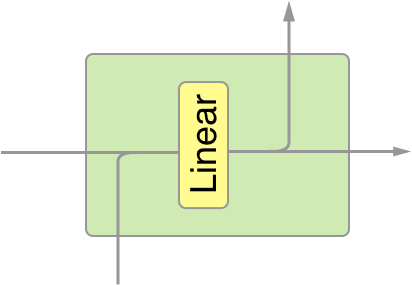


In [ ]:
import torch.nn as nn


class RNNCell(nn.Module):
    """
    Implementation of Elman RNN cell (vanilla RNN cell).
    """

    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()

        # model hyperparameters
        self.hidden_size = hidden_size

        # model layers (input to hidden)
        self.x2h = nn.Linear(input_size, hidden_size)
        self.h2h = nn.Linear(hidden_size, hidden_size)
        self.h2o = nn.Linear(hidden_size, output_size)

    # RNN forward pass
    def forward(self, input, old_hidden):
        """
        input shaped (batch, input_size)
        hidden shaped (batch, hidden_size)
        """
        # run linear layer on combined inputs (batch, hidden_size)
        hidden = torch.tanh(self.x2h(input) + self.h2h(old_hidden))
        output = self.h2o(hidden)

        return output, hidden


class RNN(nn.Module):
    """
    Implementation of full Elman RNN.
    Executes RNNCell for each of the inputs.
    """

    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()

        # model hyperparameters
        self.bidirectional = False
        self.hidden_size = hidden_size
        self.cell = RNNCell(input_size, hidden_size, output_size)

    # initialize first hidden state
    def init_hidden(self):
        return torch.zeros(1, self.hidden_size)

    # RNN forward pass
    def forward(self, input, hidden):  # batch_size, (largo_secuencia x dim_elemento_secuencia)
        # run cell on ith input (batch, hidden_size)
        output, hidden = self.cell(input, hidden)
        return output, hidden

## Creando una RNN tipo LSTM

Para implementarlo aprovecharemos el módulo LSTM que trae pytorch. Solamente nos preocuparemos de retornar los parámetros adecuados y poner la lineal de salida sobre el estado oculto de la LSTM.

![](https://colah.github.io/posts/2015-08-Understanding-LSTMs/img/LSTM3-chain.png)

from https://colah.github.io/posts/2015-08-Understanding-LSTMs

In [ ]:
class LSTM(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()

        # model hyperparameters
        self.bidirectional = False
        self.hidden_size = hidden_size
        self.cell = nn.LSTMCell(input_size, hidden_size)
        self.h2o = nn.Linear(hidden_size, output_size)

    def init_hidden(self):
        return torch.zeros(1, self.hidden_size), torch.zeros(1, self.hidden_size)

    # forward pass
    def forward(self, input, hidden):
        """
        input shape (batch, seq_len)
        """
        hidden = self.cell(input, hidden)
        output = self.h2o(hidden[0])
        return output, hidden

## Creando una RNN tipo BiLSTM

Para implementarlo aprovecharemos el módulo LSTM que trae pytorch, que asumiremos será llamado con un input leido de derecha a izquierda y otro de izquierda a derecha. Debemos preocuparnos de retornar los parámetros adecuados y poner la lineal de salida sobre el estado oculto de la LSTM-forward concatenada con la backward.

![](https://miro.medium.com/max/764/1*6QnPUSv_t9BY9Fv8_aLb-Q.png)

Source: https://towardsdatascience.com/understanding-bidirectional-rnn-in-pytorch-5bd25a5dd66

In [ ]:
class BiLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()

        # model hyperparameters
        self.bidirectional = True
        self.hidden_size = hidden_size
        self.forward_cell = nn.LSTMCell(input_size, hidden_size)
        self.backward_cell = nn.LSTMCell(input_size, hidden_size)
        self.h2o = nn.Linear(2 * hidden_size, output_size)

    def init_hidden(self):
        return (torch.zeros(1, self.hidden_size), torch.zeros(1, self.hidden_size)), (
            torch.zeros(1, self.hidden_size),
            torch.zeros(1, self.hidden_size),
        )

    # forward pass
    def forward(self, input, hidden):
        """
        input shape (batch, seq_len)
        """
        hidden = self.forward_cell(input[0], hidden[0]), self.backward_cell(input[1], hidden[1])

        # Stack outputs
        outputs_forward = hidden[0][0]
        outputs_backward = hidden[1][0]
        output = self.h2o(torch.cat((outputs_forward, outputs_backward), dim=1))

        return output, hidden

## Ahora analicemos una RNN

In [ ]:
n_hidden = 32

rnn = RNN(n_letters, n_hidden, n_categories)

In [ ]:
print(num_trainable_parameters(rnn))

3506


Para ejecutar un paso de esta red, necesitamos pasar una entrada (en nuestro caso, el tensor para la letra actual) y un estado oculto anterior (que inicializamos como ceros al principio). Obtendremos la salida (probabilidad de cada idioma, antes de softmax) y un siguiente estado oculto (que conservamos para el siguiente paso).

La razón para omitir la softmax es porque utilizaremos una implementación de CrossEntropy que tiene la softmax incorporada. Por lo mismo, si queremos visualizar las probabilidades tendremos que aplicar una softmax manualmente sobre este vector. En nuestro caso no es necesario pues solo nos interesa quedarnos con el índice del máximo (que será el mismo si aplicamos o no la softmax)




In [ ]:
input = letterToTensor("A")
print(input.shape)
hidden = rnn.init_hidden()

output, next_hidden = rnn(input, hidden)
print(output, output.shape, next_hidden, next_hidden.shape)

torch.Size([1, 57])
tensor([[ 0.2391, -0.0015,  0.2111, -0.2318, -0.1729, -0.0385, -0.2250, -0.1601,
          0.1217, -0.2498, -0.1828,  0.1860, -0.0726,  0.0209, -0.1267,  0.0279,
          0.0778, -0.0374]], grad_fn=<AddmmBackward0>) torch.Size([1, 18]) tensor([[-1.4556e-01, -2.1657e-01,  1.9990e-01, -2.6535e-01,  1.0932e-01,
          9.9310e-02,  2.6521e-01, -4.3618e-02, -2.9586e-02, -1.6683e-02,
          1.2356e-01,  7.5105e-03, -3.4147e-02, -2.6901e-01,  2.6950e-01,
          2.6246e-01, -1.9129e-01, -1.3796e-01, -4.6710e-02,  7.0765e-02,
          4.2577e-02, -9.7397e-02, -3.0250e-01, -2.7326e-01, -1.5915e-01,
          2.0645e-01, -1.1657e-01,  1.0249e-04, -3.9498e-02,  7.7012e-02,
         -8.0995e-02, -5.8285e-03]], grad_fn=<TanhBackward0>) torch.Size([1, 32])


In [ ]:
input = lineToTensor("Albert")
print(input.shape)
hidden = rnn.init_hidden()

output, next_hidden = rnn(input[0], hidden)
print(output)

torch.Size([6, 1, 57])
tensor([[ 0.2391, -0.0015,  0.2111, -0.2318, -0.1729, -0.0385, -0.2250, -0.1601,
          0.1217, -0.2498, -0.1828,  0.1860, -0.0726,  0.0209, -0.1267,  0.0279,
          0.0778, -0.0374]], grad_fn=<AddmmBackward0>)


Podemos notar que el output es un Tensor de ``<1 x n_categories>``, que es el vector de probabilidades antes de aplicarle softmax (más grande significa más probable).

Notar que estamos preservando el output correspondiente al último caracter de la palabra (que encapsula toda la información de caractyeres anteriores), con lo cual estamos pudiendo representar cualquier palabra (independiente de su largo) con un vector de tamaño fijo.




## Preparación para el entrenamiento

Primero definiremos una serie de métodos para analizar las salidas y facilitar
el sampleo de ejemplos de entrenamiento




In [ ]:
import random


def categoryFromOutput(output):
    # this function returns the category corresponding to the max value
    # in the returned probability Tensor
    top_n, top_i = output.topk(1)
    category_i = top_i[0].item()
    return all_categories[category_i], category_i


def randomChoice(l):
    return l[random.randint(0, len(l) - 1)]


def randomTrainingExample():  # Data Loader
    category = randomChoice(all_categories)
    line = randomChoice(category_lines[category])
    category_tensor = torch.tensor([all_categories.index(category)], dtype=torch.long)
    line_tensor = lineToTensor(line)
    return category, line, category_tensor, line_tensor


for i in range(10):
    category, line, category_tensor, line_tensor = randomTrainingExample()
    print("{}: {}".format(line, category))

Samaha: Arabic
Cao: Chinese
Colon: Spanish
Nazari: Arabic
Gan: Chinese
Fausti: Italian
Allwood: English
Daly: Irish
Loyola: Spanish
Pei: Chinese


### Entrenamiento

Nota importante: Para evitar tener que trabajar con paddings y detener la iteración de manera distinta para cada elemento del batch según su largo original (antes de paddings) trabajaremos con batches de tamaño 1. Si usted necesita trabajar con batches de mayor tamaño, resulta ser un poco más complejo de implementar (por esa razón lo omitimos de este laboratorio). Para referencia, esto se puede hacer mediante las funcionalidades de torch.nn.utils.rnn llamadas pack_padded_sequence y pad_packed_sequence (tutorial en https://gist.github.com/HarshTrivedi/f4e7293e941b17d19058f6fb90ab0fec)

Para comenzar crearemos nuestro objeto a cargo de evaluar la función de pérdida:





In [ ]:
criterion = nn.CrossEntropyLoss()

A continuación creamos una serie de métodos para entrenar, evaluar y graficar resultados de los modelos.

Cada ciclo de entrenamiento hará lo siguiente:

- Creará los tensores de entrada y objetivo.
- Seteará el estado oculto inicial con valores cero.
- Leerá cada letra de la entrada y mantendrá el estado oculto para entregárselo a la siguiente letra.
- Comparará la salida final con el objetivo.
- Realizará el backpropagation.
- Retornará la salida y la función de pérdida.




In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import time
import math

learning_rate = 0.005  # If you set this too high, it might explode. If too low, it might not learn


def train(category_tensor, line_tensor, model):
    hidden = model.init_hidden()

    model.zero_grad()

    for i in range(line_tensor.size()[0]):
        if model.bidirectional:
            output, hidden = model(
                (line_tensor[i], line_tensor[line_tensor.size()[0] - i - 1]), hidden
            )
        else:
            output, hidden = model(line_tensor[i], hidden)

    loss = criterion(output, category_tensor)
    loss.backward()

    # Add parameters' gradients to their values, multiplied by learning rate
    for p in model.parameters():
        p.data.add_(p.grad.data, alpha=-learning_rate)  # SGD HECHO A MANO!!!!

    # optimizer.step()

    return output, loss.item()


def timeSince(since):
    now = time.time()
    s = now - since
    m = math.floor(s / 60)
    s -= m * 60
    return "%dm %ds" % (m, s)


def train_model(model, n_iters=200000, print_every=10000, plot_every=1000):

    # Keep track of losses for plotting
    current_loss = 0
    all_losses = []

    start = time.time()

    for iter in range(1, n_iters + 1):
        category, line, category_tensor, line_tensor = randomTrainingExample()
        output, loss = train(category_tensor, line_tensor, model)
        current_loss += loss

        # Print ``iter`` number, loss, name and guess
        if iter % print_every == 0:
            guess, guess_i = categoryFromOutput(output)
            correct = "✓" if guess == category else "✗ (%s)" % category
            print(
                "%d %d%% (%s) %.4f %s / %s %s"
                % (iter, iter / n_iters * 100, timeSince(start), loss, line, guess, correct)
            )

        # Add current loss avg to list of losses
        if iter % plot_every == 0:
            all_losses.append(current_loss / plot_every)
            current_loss = 0

    return all_losses, model


def plot_loss(all_losses):
    plt.figure()
    plt.plot(all_losses)


# Just return an output given a line
def evaluate(line_tensor, model):
    hidden = model.init_hidden()

    for i in range(line_tensor.size()[0]):
        if model.bidirectional:
            output, hidden = model(
                (line_tensor[i], line_tensor[line_tensor.size()[0] - i - 1]), hidden
            )
        else:
            output, hidden = model(line_tensor[i], hidden)

    return output


def compute_confusion_matrix(model):
    # Keep track of correct guesses in a confusion matrix
    confusion = torch.zeros(n_categories, n_categories)
    n_confusion = 10000

    # Go through a bunch of examples and record which are correctly guessed
    for i in range(n_confusion):
        category, line, category_tensor, line_tensor = randomTrainingExample()
        output = evaluate(line_tensor, model)
        guess, guess_i = categoryFromOutput(output)
        category_i = all_categories.index(category)
        confusion[category_i][guess_i] += 1

    # Normalize by dividing every row by its sum
    for i in range(n_categories):
        confusion[i] = confusion[i] / confusion[i].sum()

    # Set up plot
    fig = plt.figure()
    ax = fig.add_subplot(111)
    cax = ax.matshow(confusion.numpy())
    fig.colorbar(cax)

    # Set up axes
    ax.set_xticklabels([""] + all_categories, rotation=90)
    ax.set_yticklabels([""] + all_categories)

    # Force label at every tick
    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(1))

    # sphinx_gallery_thumbnail_number = 2
    plt.show()

### Ahora a entrenar!

Mediante el método ``train_model`` entrenaremos los tres modelos.

NOTA:  Si tiene restricciones de tiempo, puede reducir el parámetro ``n_iters`` a la mitad para que finalice antes. En este caso usaremos 200K iteraciones.

Luego de entrenado graficaremos la trayectoria de la función de pérdida almacenada en ``all_losses``, y finalmente mostraremos la matriz de confusión asociada a las predicciones de cada modelo, usando ``compute_confusion_matrix``.




In [ ]:
n_hidden = 147
model = RNN(n_letters, n_hidden, n_categories)
all_losses, model = train_model(model, n_iters=200000)

10000 5% (0m 19s) 0.6414 Zdunowski / Polish ✓
20000 10% (0m 37s) 1.0654 Machacek / Czech ✓
30000 15% (0m 56s) 0.4366 Bing / Chinese ✓
40000 20% (1m 14s) 0.9329 Bolivar / Spanish ✓
50000 25% (1m 32s) 6.3424 Lis / Chinese ✗ (Polish)
60000 30% (1m 49s) 0.4571 Zunino / Italian ✓
70000 35% (2m 7s) 2.2646 Tse / German ✗ (Chinese)
80000 40% (2m 25s) 0.4064 Hajjar / Arabic ✓
90000 45% (2m 42s) 0.0106 Katayama / Japanese ✓
100000 50% (3m 0s) 0.0389 Pham / Vietnamese ✓
110000 55% (3m 18s) 0.0097 O'Brien / Irish ✓
120000 60% (3m 36s) 0.2592 Falco / Italian ✓
130000 65% (3m 54s) 1.1926 Prince / German ✗ (English)
140000 70% (4m 12s) 0.0207 Sarkis / Arabic ✓
150000 75% (4m 29s) 0.2426 Reijnder / Dutch ✓
160000 80% (4m 47s) 0.2548 Orellana / Spanish ✓
170000 85% (5m 6s) 7.0012 Gach / German ✗ (Russian)
180000 90% (5m 23s) 1.6769 Mai / Chinese ✗ (Vietnamese)
190000 95% (5m 42s) 0.0747 Winograd / Polish ✓
200000 100% (5m 59s) 4.5720 Murtas / Spanish ✗ (Italian)


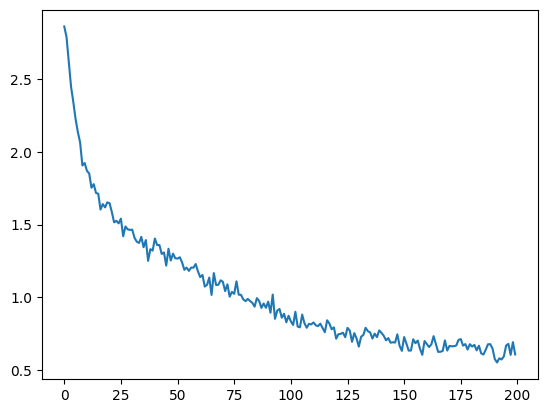

In [ ]:
plot_loss(all_losses)

/tmp/ipykernel_4747/938344581.py:105: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + all_categories, rotation=90)
/tmp/ipykernel_4747/938344581.py:106: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + all_categories)


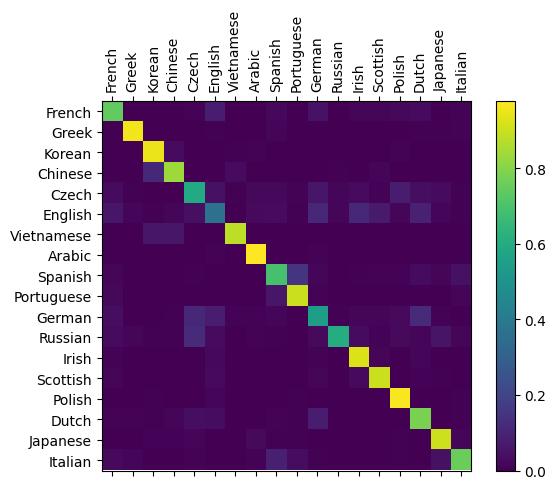

In [ ]:
compute_confusion_matrix(model)

In [ ]:
n_hidden = 64
model = LSTM(n_letters, n_hidden, n_categories)
all_losses, model = train_model(model, n_iters=200000)

10000 5% (0m 27s) 2.8103 Close / Irish ✗ (Greek)
20000 10% (0m 54s) 2.6024 Arakawa / Polish ✗ (Japanese)
30000 15% (1m 22s) 2.9124 Michel / English ✗ (Spanish)
40000 20% (1m 49s) 0.5738 Poniros / Greek ✓
50000 25% (2m 16s) 0.1433 Bertsimas / Greek ✓


KeyboardInterrupt: 

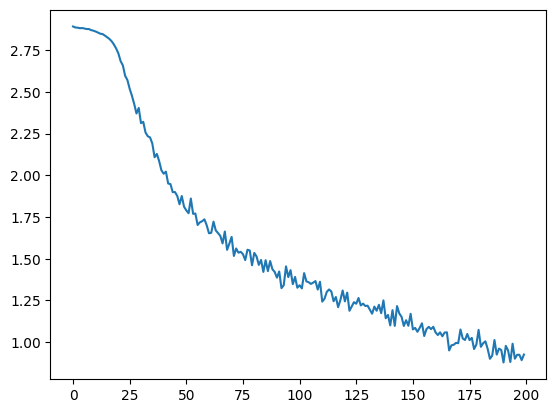

In [ ]:
plot_loss(all_losses)

/tmp/ipykernel_818/938344581.py:105: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + all_categories, rotation=90)
/tmp/ipykernel_818/938344581.py:106: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + all_categories)


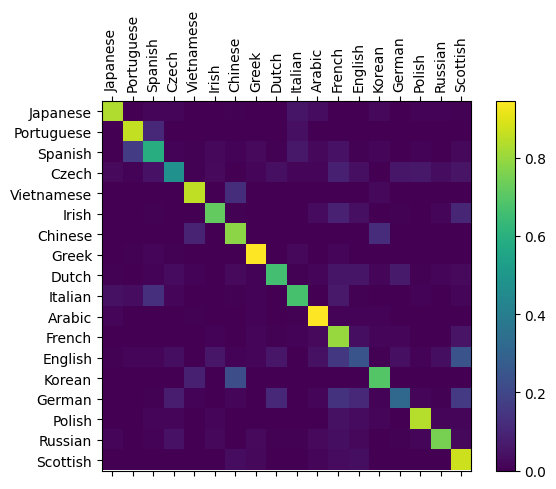

In [ ]:
compute_confusion_matrix(model)

In [ ]:
n_hidden = 40
model = BiLSTM(n_letters, n_hidden, n_categories)
all_losses, model = train_model(model, n_iters=200000)

10000 5% (0m 48s) 2.8740 Jung  / Polish ✗ (Korean)
20000 10% (1m 37s) 2.9415 Zeng / Korean ✗ (Chinese)
30000 15% (2m 26s) 0.5789 Chrysanthopoulos / Greek ✓
40000 20% (3m 15s) 1.5669 Leveque / French ✓
50000 25% (4m 4s) 1.6454 Utterson / English ✓
60000 30% (4m 52s) 1.1231 Ferreiro / Italian ✗ (Portuguese)
70000 35% (5m 41s) 1.3809 Albero / Spanish ✗ (Italian)
80000 40% (6m 29s) 2.8623 Krol / Czech ✗ (Polish)
90000 45% (7m 18s) 1.5940 Kaufer / Arabic ✗ (German)
100000 50% (8m 7s) 0.2407 Pharlain / Irish ✓
110000 55% (8m 56s) 0.8990 Skala / Polish ✓
120000 60% (9m 44s) 0.5350 Yim / Korean ✓
130000 65% (10m 33s) 3.6894 MaxaB / Arabic ✗ (Czech)
140000 70% (11m 21s) 0.7964 Palomer / French ✓
150000 75% (12m 10s) 1.5657 Gok / Korean ✗ (Chinese)
160000 80% (12m 58s) 4.1271 Morcos / Portuguese ✗ (Arabic)
170000 85% (13m 47s) 0.2256 Wilson / Scottish ✓
180000 90% (14m 36s) 0.1566 Maestri / Italian ✓
190000 95% (15m 25s) 1.3968 Klerkse / German ✗ (Dutch)
200000 100% (16m 14s) 0.3179 Thao / Vietn

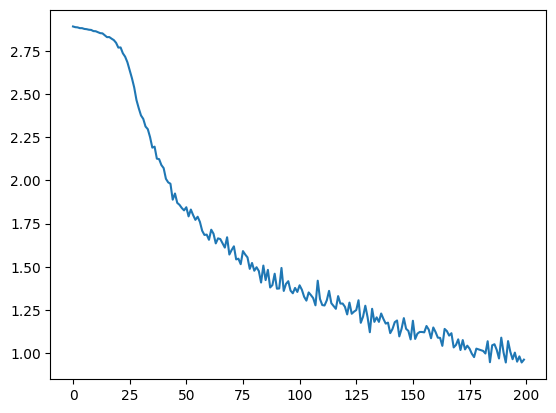

In [ ]:
plot_loss(all_losses)

/tmp/ipykernel_818/938344581.py:105: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + all_categories, rotation=90)
/tmp/ipykernel_818/938344581.py:106: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + all_categories)


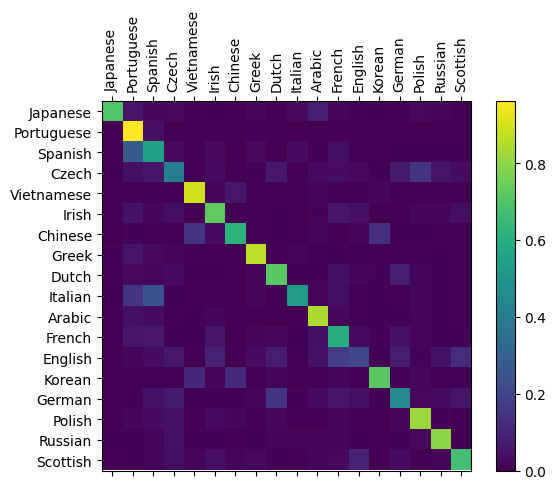

In [ ]:
compute_confusion_matrix(model)

En este caso podemos ver que no existe demasiada diferencia entre las tres arquitecturas (aunque para saberlo con certeza habría que hacer una mejor búsqueda de hiperparámetros y evaluar correctamente, lo cual no era parte de este laboratorio).
A primera vista vemos que los tres modelos parecen comportarse de manera similar. Una posible explicación es debido a que este dataset es muy pequeño y no logra aprovechar las capacidades de modelos más sofisticados como la LSTM y la BiLSTM. En escenarios más realistas (más datos y tareas más desafiantes) es esperable que la LSTM supere largamente a la RNN simple, y que la BiLSTM supere a la LSTM.

## Evaluación manual

Por completitud, a continuación dejamos un código para evaluar el modelo en ejemplos definidos manualmente, por si usted desea utilizarlo de esta manera.




In [ ]:
def predict(input_line, n_predictions=3):
    print("\n> %s" % input_line)
    with torch.no_grad():
        output = evaluate(lineToTensor(input_line), model)

        # Get top N categories
        topv, topi = output.topk(n_predictions, 1, True)
        predictions = []

        for i in range(n_predictions):
            value = topv[0][i].item()
            category_index = topi[0][i].item()
            print("(%.2f) %s" % (value, all_categories[category_index]))
            predictions.append([value, all_categories[category_index]])


predict("Dovesky")
predict("Jackson")
predict("Satoshi")
predict("Muñoz")
predict("Raymond")


> Dovesky
(7.28) Russian
(6.80) Czech
(4.72) Polish

> Jackson
(6.53) Scottish
(4.92) English
(4.67) Russian

> Satoshi
(6.68) Japanese
(5.83) Arabic
(3.09) Polish

> Muñoz
(4.45) Spanish
(3.01) Portuguese
(2.52) Polish

> Raymond
(4.81) English
(4.65) Irish
(4.43) French


# Actividad 1

- Mencione la dimensionalidad oculta de los 3 modelos ejecutados en este laboratorio, calcule su cantidad de parámetros y explique por qué no sería justo utilizar dimensionalidad oculta pareja para todos los modelos.

- El modelo RNN vanilla tiene una dimensionalidad oculta de 147
- El modelo LSTM tiene una dimensionalidad oculta de 64
- El modelo BiLSTM tiene una dimensionalidad oculta de 40 en cada dirección

In [ ]:
n_hidden_rnn = 147
modelo_rnn = RNN(n_letters, n_hidden_rnn, n_categories)

n_hidden_lstm = 64
modelo_lstm = LSTM(n_letters, n_hidden_lstm, n_categories)

n_hidden_bilstm = 40
modelo_bilstm = BiLSTM(n_letters, n_hidden_bilstm, n_categories)

In [ ]:
print(f"Parametros modelo RNN vanilla: {num_trainable_parameters(modelo_rnn)}")
print(f"Parametros modelo LSTM: {num_trainable_parameters(modelo_lstm)}")
print(f"Parametros modelo BiLSTM: {num_trainable_parameters(modelo_bilstm)}")

Parametros modelo RNN vanilla: 32946
Parametros modelo LSTM: 32658
Parametros modelo BiLSTM: 33138


Si vemos los resultados de los parámetros para cada modelo, apreciamos que los 3 tienen una cantidad de parámetros similar entre sí. Lo anterior se debe a que fuimos disminuyendo gradualmente la dimensionalidad oculta de cada modelo mientras más complejos se hacía.

## ¿Que ocurriría si es que todos los modelos tienen la misma dimensionalidad oculta que el modelo RNN vanilla? Observemos:

In [ ]:
n_hidden_rnn = 147
modelo_rnn = RNN(n_letters, n_hidden_rnn, n_categories)

n_hidden_lstm = 147
modelo_lstm = LSTM(n_letters, n_hidden_lstm, n_categories)

n_hidden_bilstm = 147
modelo_bilstm = BiLSTM(n_letters, n_hidden_bilstm, n_categories)

In [ ]:
print(f"Parametros modelo RNN vanilla: {num_trainable_parameters(modelo_rnn)}")
print(f"Parametros modelo LSTM: {num_trainable_parameters(modelo_lstm)}")
print(f"Parametros modelo BiLSTM: {num_trainable_parameters(modelo_bilstm)}")

Como vemos, la cantidad de parámetros aumenta drásticamente a medida que los modelos se vuelven más complejos.

Por lo mismo, optamos por ajustar la dimensionalidad oculta en cada caso. Usar el mismo valor para todos habría significado más parámetros, tiempos de entrenamiento más largos y mayor riesgo de sobreajuste en los modelos más elaborados.

# Actividad 2

Agregue otra capa lineal con una ReLU al clasificador del modelo de LSTM (no bidireccional) como se muestra en la figura.

Pruebe variantes de 50, 150 y 300 neuronas en la capa oculta.

- Grafique la pérdida para las 3 y comente.
- Calcule la cantidad de parámetros de los tres modelos y comente.

*(Consejo: debe tener dos capas `linear`, y se necesita una activación entre ellas)*

| A la izquierda se muestra diagrama actual de salida de la red. Implementar el de la izquierda agregando otra capa. |
| :--: |
| 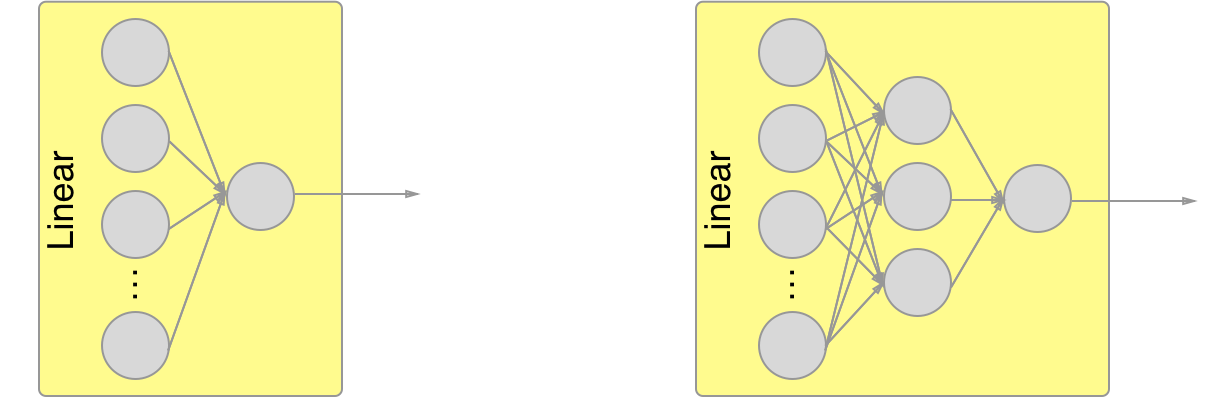 |



In [ ]:
n_hidden = 64

# Define el estado inicial de los modelos
model_linear_50 = LSTM(n_letters, n_hidden, n_categories)
model_linear_150 = LSTM(n_letters, n_hidden, n_categories)
model_linear_300 = LSTM(n_letters, n_hidden, n_categories)

In [ ]:
model_linear_50.h2o = nn.Sequential(
    nn.Linear(in_features=n_hidden, out_features=50),
    nn.ReLU(),
    nn.Linear(in_features=50, out_features=n_categories),
)
all_losses_50, model_linear_50 = train_model(model_linear_50, n_iters=200000)

10000 5% (0m 33s) 2.8712 Isa / Korean ✗ (Arabic)
20000 10% (1m 5s) 2.7989 Altoviti / Greek ✗ (Italian)
30000 15% (1m 38s) 2.3887 Quach / Chinese ✗ (Vietnamese)
40000 20% (2m 11s) 2.0673 Fuchida / Czech ✗ (Japanese)
50000 25% (2m 44s) 2.0992 Tsai  / Arabic ✗ (Korean)
60000 30% (3m 16s) 2.7145 Krantz / Spanish ✗ (Dutch)
70000 35% (3m 49s) 1.1215 Mao / Chinese ✓
80000 40% (4m 22s) 1.8691 Rudd / German ✗ (English)
90000 45% (4m 55s) 1.0531 Bui / Chinese ✓
100000 50% (5m 28s) 0.7945 Hao / Chinese ✓
110000 55% (6m 0s) 1.0424 Brian / Irish ✓
120000 60% (6m 33s) 0.5057 Hao / Chinese ✓
130000 65% (7m 6s) 1.6878 Mclain / Scottish ✗ (Irish)
140000 70% (7m 39s) 2.3112 Tyman / Russian ✗ (English)
150000 75% (8m 12s) 0.0220 Sfakianos / Greek ✓
160000 80% (8m 45s) 0.2594 Starek / Polish ✓
170000 85% (9m 17s) 2.5644 Bakhtadze / Japanese ✗ (Russian)
180000 90% (9m 50s) 0.0853 Haanraats / Dutch ✓
190000 95% (10m 23s) 0.0514 Ta / Vietnamese ✓
200000 100% (10m 55s) 2.7139 Puig / Chinese ✗ (Spanish)


In [ ]:
model_linear_150.h2o = nn.Sequential(
    nn.Linear(in_features=n_hidden, out_features=150),
    nn.ReLU(),
    nn.Linear(in_features=150, out_features=n_categories),
)
all_losses_150, model_linear_150 = train_model(model_linear_150, n_iters=200000)

10000 5% (0m 34s) 2.8531 Habicht / English ✗ (German)
20000 10% (1m 8s) 2.7575 Cham / Arabic ✓
30000 15% (1m 43s) 2.5344 Guillory / Dutch ✗ (French)
40000 20% (2m 17s) 2.2172 Allard / French ✓
50000 25% (2m 52s) 0.9828 Sung / Korean ✓
60000 30% (3m 26s) 2.0976 Scolaidhe / English ✗ (Irish)
70000 35% (4m 0s) 2.3030 Bazzi / Japanese ✗ (Arabic)
80000 40% (4m 35s) 2.2223 Inker / German ✗ (English)
90000 45% (5m 9s) 0.7199 Rudaski / Polish ✓
100000 50% (5m 43s) 1.0228 Belo / Portuguese ✓
110000 55% (6m 17s) 2.8418 Seaghdha / Portuguese ✗ (Irish)
120000 60% (6m 52s) 0.1193 Dalianis / Greek ✓
130000 65% (7m 26s) 0.9824 Olivier / French ✓
140000 70% (8m 1s) 1.4625 Ngo / Korean ✗ (Vietnamese)
150000 75% (8m 36s) 1.1104 Devin / Irish ✓
160000 80% (9m 10s) 0.9894 Karube / Japanese ✓
170000 85% (9m 45s) 2.9820 Mullen / German ✗ (Irish)
180000 90% (10m 19s) 0.3916 Quyen / Vietnamese ✓
190000 95% (10m 54s) 2.5639 Zaruba / Japanese ✗ (Czech)
200000 100% (11m 29s) 0.3772 Rim / Korean ✓


In [ ]:
model_linear_300.h2o = nn.Sequential(
    nn.Linear(in_features=n_hidden, out_features=300),
    nn.ReLU(),
    nn.Linear(in_features=300, out_features=n_categories),
)
all_losses_300, model_linear_300 = train_model(model_linear_300, n_iters=200000)

10000 5% (0m 34s) 2.9395 Huan / Irish ✗ (Chinese)
20000 10% (1m 8s) 2.2915 Ta / Vietnamese ✓
30000 15% (1m 42s) 2.1292 Yoshihara / Polish ✗ (Japanese)
40000 20% (2m 16s) 1.9865 Bell / English ✗ (Scottish)
50000 25% (2m 50s) 2.6572 Mata / Japanese ✗ (Portuguese)
60000 30% (3m 24s) 2.5505 Flores / French ✗ (Spanish)
70000 35% (3m 58s) 1.6039 Maroun / French ✗ (Arabic)
80000 40% (4m 32s) 0.0112 Hautiev / Russian ✓
90000 45% (5m 6s) 0.3681 Fernandez / Spanish ✓
100000 50% (5m 40s) 1.0064 Luttrell / English ✓
110000 55% (6m 14s) 1.3804 Glasgow / Scottish ✗ (English)
120000 60% (6m 48s) 0.9209 Wood / Scottish ✓
130000 65% (7m 24s) 0.5879 Sniders / Dutch ✓
140000 70% (7m 58s) 3.9385 Mcnamara / Arabic ✗ (English)
150000 75% (8m 31s) 3.1619 Martin / French ✗ (German)
160000 80% (9m 5s) 0.3069 Doan / Vietnamese ✓
170000 85% (9m 39s) 0.5583 Michael / Irish ✓
180000 90% (10m 12s) 1.9253 Mohren / Dutch ✗ (German)
190000 95% (10m 46s) 0.0074 Kowalski / Polish ✓
200000 100% (11m 20s) 0.1262 Ophoven /

Modelo con capa lineal de 50 neuronas:


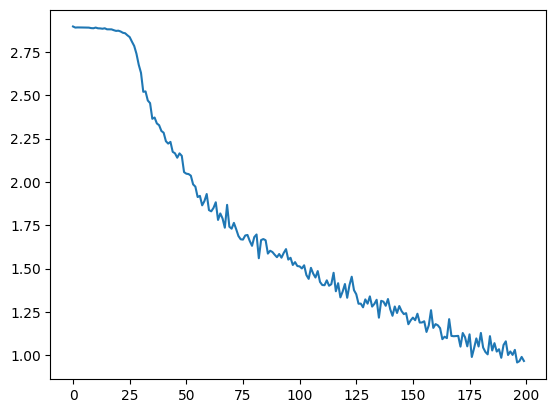

In [ ]:
print("Modelo con capa lineal de 50 neuronas:")
(plot_loss(all_losses_50))

Modelo con capa lineal de 150 neuronas:


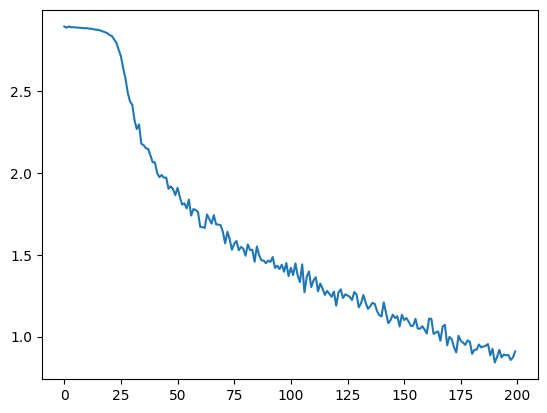

In [ ]:
print("Modelo con capa lineal de 150 neuronas:")
(plot_loss(all_losses_150))

Modelo con capa lineal de 300 neuronas:


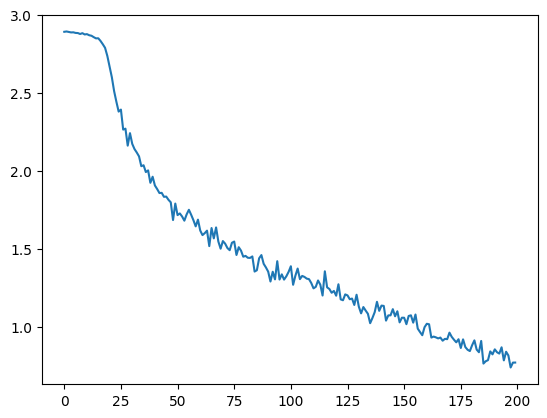

In [ ]:
print("Modelo con capa lineal de 300 neuronas:")
(plot_loss(all_losses_300))

In [ ]:
print(f"Parametros modelo linear 50: {num_trainable_parameters(model_linear_50)}")
print(f"Parametros modelo linear 150: {num_trainable_parameters(model_linear_150)}")
print(f"Parametros modelo linear 300: {num_trainable_parameters(model_linear_300)}")

Parametros modelo linear 50: 35656
Parametros modelo linear 150: 43956
Parametros modelo linear 300: 56406


Al comparar los 3 nuevos modelos, observamos lo siguiente:

Mientras más neuronas agregamos a la capa lineal nueva, más tiempo se demoraban los modelos en aprender y disminuir su perdida. Si comparamos la baja en la perdida a las 50k iteraciones, vemos que el modelo que tenía 50 neuronas en la capa lineal disminuyó drásticamente su perdida, llegando a valores aproximados de 0.5. Por otro lado, tanto el modelo con 150 neuronas y el modelo de 300 neuronas llegaron a una pérdida de aproximadamente 1.6. Cuando comparamos los modelos de 150 y 300 neuronas, vemos que a la iteración 150k, el primero de estos modelos ya estaba llegando a una pérdida de 1, mientras que el segundo todavía estaba en valores de 1.2. Por lo tanto, a mayor cantidad de parámetros, más dificil era disminuir la perdida.